In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
data = pd.read_parquet("processed_wallet_fraud_dataset.parquet")

In [3]:
data.head()

,address,flag,avg_min_between_sent_tnx,avg_min_between_received_tnx,time_diff_between_first_and_last_mins,sent_tnx,received_tnx,number_of_created_contracts,unique_received_from_addresses,unique_sent_to_addresses,...,received_range_ratio,addr_dispersion_sent,addr_dispersion_received,erc20_tx_ratio,erc20_sent_flag,log_erc20_uniq_sent_addr,log_erc20_uniq_rec_addr,erc20_addr_balance_ratio,log_erc20_unique_tokens_sent,log_erc20_unique_tokens_rec
0,0x00009277775ac7d0d59eaad8fee3d10ac6c805e8,0,844.26,1093.71,704785.63,721,89,0,40,118,...,6.035537,0.163435,0.444444,0.326757,1,3.433987,4.007333,0.545455,3.688879,4.060443
1,0x0002b44ddb1476db43c868bd494422ee4c136fed,0,12709.07,2958.44,1218216.73,94,8,0,5,14,...,1.885904,0.147368,0.555556,0.077670,1,0.693147,1.791759,0.166667,0.693147,2.079442
2,0x0002bda54cb772d040f779e88eb453cac0daa244,0,246194.54,2434.02,516729.30,2,10,0,10,2,...,0.857641,0.666667,0.909091,0.615385,0,0.000000,2.079442,0.000000,0.000000,2.197225
3,0x00038e6ba2fd5c09aedb96697c8d7b8fa6632e5e,0,10219.60,15785.09,397555.90,25,9,0,7,13,...,4.975677,0.500000,0.700000,0.400000,1,1.098612,2.484907,0.166667,0.693147,2.484907
4,0x00062d1dd1afb6fb02540ddad9cdebfe568e0d89,0,36.61,10707.77,382472.42,4598,20,1,7,19,...,3.487355,0.004131,0.333333,0.009091,1,1.609438,3.178054,0.166667,1.945910,3.332205


## Part 1: Model development, evaluation and top features

A range of machine learning models were employed to capture different structural properties of the data, including linear relationships (Logistic Regression), rule-based interactions (Decision Trees), ensemble learning (Random Forest and Gradient Boosting), and boundary-based classification (SVM). This approach enables robust comparison and selection of the most effective model for fraud detection.

### 0. General model prep steps

In [4]:
addresses = data["address"]
X = data.drop(columns=["address", "flag"])
y = data['flag']

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

In [6]:
#train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=67,
    #to preserve the class distribution between training and test sets
    #especially bc dataset is imbalanced
    stratify=y
)

In [7]:
#scaling to ensure consistent scale across variables
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
def evaluate_model(model_name, y_test, y_pred, y_prob):
    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }
    
    df = pd.DataFrame([metrics])
    
    print(f"\n{model_name} Evaluation")
    print(df.round(3))
    
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    return df

### 1. Logistic Regression (baseline)

Logistic Regression was selected as a baseline model to establish a performance benchmark using a simple linear decision boundary. Its probabilistic outputs enable risk scoring, while its interpretability allows for direct assessment of feature influence. This provides a reference point against which more complex models can be evaluated.

In [9]:
from sklearn.linear_model import LogisticRegression

#training
log_reg = LogisticRegression(
    max_iter=1000,
    #adjusting class weights to account for class imbalance, 
    #increasing the penalty for misclassifying fraudulent cases and improving detection performance.
    class_weight="balanced",
    random_state=67
)

log_reg.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",67
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [10]:
#model predictions and evalution metrics table 
y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

#calling the evaluation metrics function
lr_metrics = evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred_lr,
    y_prob_lr
)


Logistic Regression Evaluation
                 Model  Accuracy  Precision  Recall  F1-score  ROC-AUC
0  Logistic Regression     0.867      0.642   0.907     0.752    0.946

Confusion Matrix:
[[1960  331]
 [  61  593]]


The Logistic Regression model demonstrates strong fraud detection capability, achieving a recall of 0.91, meaning that the majority of fraudulent cases are correctly identified. This comes at the cost of lower precision (0.64), indicating a higher number of false positives. However, in the context of fraud detection, prioritising recall is appropriate to minimise missed fraudulent activity. The high ROC-AUC (0.95) further indicates strong ability to rank accounts by fraud risk, supporting the use of probability-based risk scoring.

The strong performance of Logistic Regression suggests that a substantial portion of the predictive signal can be captured through linear relationships between the engineered features and fraud likelihood.

In [11]:
lr_features = pd.DataFrame({
    "feature": X.columns,
    "coefficient": log_reg.coef_[0]
})

lr_features["abs_coefficient"] = lr_features["coefficient"].abs()

lr_top_features = (
    lr_features
    .sort_values("abs_coefficient", ascending=False)
    .head(10)
)

lr_top_features

,feature,coefficient,abs_coefficient
19,log_avg_val_received,-2.880819,2.880819
3,sent_tnx,-2.518330,2.518330
2,time_diff_between_first_and_last_mins,-2.014547,2.014547
31,log_erc20_unique_tokens_sent,1.622837,1.622837
7,unique_sent_to_addresses,1.519454,1.519454
11,sent_received_ratio,-1.493203,1.493203
17,log_total_ether_received,-1.452703,1.452703
26,erc20_tx_ratio,1.219209,1.219209
18,log_avg_val_sent,1.168091,1.168091
8,total_transactions_including_tnx_to_create_con...,-1.078193,1.078193


### 2. Decision Tree

A Decision Tree model was implemented to capture non-linear relationships and interaction effects between features, providing an interpretable rule-based representation of fraud detection.

In [12]:
from sklearn.tree import DecisionTreeClassifier

#training
dt = DecisionTreeClassifier(
    #prevents overfitting
    max_depth=5,          
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=67
)

dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",67
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [13]:
#model predictions
y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

#calling metrics function
dt_metrics = evaluate_model(
    "Decision Tree",
    y_test,
    y_pred_dt,
    y_prob_dt
)


Decision Tree Evaluation
           Model  Accuracy  Precision  Recall  F1-score  ROC-AUC
0  Decision Tree     0.925      0.888    0.76     0.819    0.942

Confusion Matrix:
[[2228   63]
 [ 157  497]]


The Decision Tree model achieves higher precision (0.89), indicating that flagged cases are more likely to be truly fraudulent, reducing false positives. However, this comes at the cost of lower recall (0.76), meaning more fraudulent cases are missed compared to Logistic Regression. This highlights a trade-off between detection sensitivity and investigation efficiency.

While Logistic Regression prioritises capturing fraudulent activity, the Decision Tree adopts a more conservative approach, identifying fewer but more certain fraud cases.

In [14]:
#feature importance
dt_features = pd.DataFrame({
    "feature": X.columns,
    "importance": dt.feature_importances_
})

dt_top_features = (
    dt_features
    .sort_values("importance", ascending=False)
    .head(10)
)

dt_top_features

,feature,importance
21,log_abs_total_ether_balance,0.387056
25,addr_dispersion_received,0.277526
11,sent_received_ratio,0.105760
2,time_diff_between_first_and_last_mins,0.070322
26,erc20_tx_ratio,0.047550
17,log_total_ether_received,0.044718
1,avg_min_between_received_tnx,0.034756
30,erc20_addr_balance_ratio,0.017429
19,log_avg_val_received,0.005951
13,reaction_speed_ratio,0.003445


### 3. Random Forest

Random Forest was implemented as an ensemble learning method to improve predictive performance and reduce overfitting by aggregating multiple decision trees, enabling robust detection of complex, non-linear fraud patterns.

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(
    class_weight="balanced",
    random_state=67,
    n_jobs=-1
)

#choosing optimal prameters
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [10, 20],
    "min_samples_leaf": [5, 10]
}

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    # good balance between precision and recall
    scoring="f1",        
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=67)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_leaf': [5, 10], 'min_samples_split': [10, 20], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter ca

In [17]:
#optimal prameters
grid_rf.best_params_

{'max_depth': None,
 'min_samples_leaf': 5,
 'min_samples_split': 10,
 'n_estimators': 100}

In [18]:
#average F1-score across 5 folds
grid_rf.best_score_

np.float64(0.9017190319107453)

In [19]:
#model predictions with best params
best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

rf_metrics = evaluate_model(
    "Random Forest",
    y_test,
    y_pred_rf,
    y_prob_rf
)


Random Forest Evaluation
           Model  Accuracy  Precision  Recall  F1-score  ROC-AUC
0  Random Forest     0.959      0.916   0.898     0.907    0.989

Confusion Matrix:
[[2237   54]
 [  67  587]]


The Random Forest model achieved the best overall performance, with high precision (0.92) and recall (0.90), indicating both effective fraud detection and low false positive rates. The near-perfect ROC-AUC (0.99) demonstrates exceptional ability to rank accounts by fraud risk, making it the most suitable model for the risk scoring framework.

Compared to Logistic Regression and Decision Tree models, Random Forest captures complex non-linear interactions while maintaining robustness through ensemble averaging, resulting in superior predictive performance.

In [20]:
#feature importance
rf_features = pd.DataFrame({
    "feature": X.columns,
    "importance_rf": best_rf.feature_importances_
})

rf_top_features = (
    rf_features
    .sort_values("importance_rf", ascending=False)
    .head(10)
)

rf_top_features

,feature,importance_rf
25,addr_dispersion_received,0.109565
19,log_avg_val_received,0.085180
2,time_diff_between_first_and_last_mins,0.076674
17,log_total_ether_received,0.074038
11,sent_received_ratio,0.071830
21,log_abs_total_ether_balance,0.059022
1,avg_min_between_received_tnx,0.053891
16,log_total_ether_sent,0.050681
6,unique_received_from_addresses,0.034910
8,total_transactions_including_tnx_to_create_con...,0.033938


### 4. Gradient Boosting

Gradient Boosting was selected as a boosting ensemble method to complement the baseline (Logistic Regression) and bagging approach (Random Forest). Unlike Random Forest, which builds trees independently, Gradient Boosting trains models sequentially, with each new tree focusing on correcting the errors of the previous ensemble.

In [21]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=67)

param_grid_gb = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3, 4],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 3, 5]
}

grid_gb = GridSearchCV(
    estimator=gb,
    param_grid=param_grid_gb,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

grid_gb.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=67)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.05, 0.1], 'max_depth': [2, 3, ...], 'min_samples_leaf': [1, 3, ...], 'min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and

In [22]:
grid_gb.best_params_

{'learning_rate': 0.1,
 'max_depth': 4,
 'min_samples_leaf': 5,
 'min_samples_split': 2,
 'n_estimators': 200}

In [23]:
grid_gb.best_score_

np.float64(0.989712976951321)

In [24]:
best_gb = grid_gb.best_estimator_

y_pred_gb = best_gb.predict(X_test)
y_prob_gb = best_gb.predict_proba(X_test)[:, 1]

gb_metrics = evaluate_model(
    "Gradient Boosting",
    y_test,
    y_pred_gb,
    y_prob_gb
)


Gradient Boosting Evaluation
               Model  Accuracy  Precision  Recall  F1-score  ROC-AUC
0  Gradient Boosting     0.963      0.955   0.876     0.914    0.989

Confusion Matrix:
[[2264   27]
 [  81  573]]


The Gradient Boosting model achieved strong overall performance, with high precision (0.96) and slightly lower recall (0.88), indicating effective identification of fraudulent accounts while further reducing false positive rates. The near-perfect ROC-AUC (0.99) demonstrates excellent ability to rank accounts by fraud risk, confirming its suitability for a risk scoring framework.

Compared to Random Forest, Gradient Boosting produces more conservative predictions, prioritising precision over recall. While this results in fewer false alerts, it comes at the cost of missing a small proportion of fraud cases. Nonetheless, the model effectively captures complex non-linear relationships through sequential learning, making it a strong alternative depending on business priorities

In [25]:
# feature importance (Gradient Boosting)
gb_features = pd.DataFrame({
    "feature": X.columns,
    "importance_gb": best_gb.feature_importances_
})

gb_top_features = (
    gb_features
    .sort_values("importance_gb", ascending=False)
    .head(10)
)

gb_top_features

,feature,importance_gb
21,log_abs_total_ether_balance,0.272412
25,addr_dispersion_received,0.210230
2,time_diff_between_first_and_last_mins,0.091144
11,sent_received_ratio,0.089943
1,avg_min_between_received_tnx,0.064400
19,log_avg_val_received,0.053432
26,erc20_tx_ratio,0.043346
17,log_total_ether_received,0.041437
15,net_flow,0.028290
30,erc20_addr_balance_ratio,0.022358


### Conclusion:
Across all models, Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting were evaluated to assess different modelling approaches to fraud detection.

Logistic Regression provided a useful baseline but was limited in capturing complex non-linear relationships in the data. The Decision Tree improved flexibility but remained prone to overfitting and did not achieve the same level of generalisation as ensemble methods.

Both ensemble models significantly outperformed the baseline approaches, achieving near-identical and very high ROC-AUC scores (0.99), indicating strong ability to rank accounts by fraud risk. However, their classification behaviour differed:

Random Forest achieved higher recall, making it more effective at detecting fraudulent accounts and minimising missed fraud cases.
Gradient Boosting achieved higher precision, reducing false positives and improving efficiency in downstream investigation processes.

Overall, Random Forest represents the most balanced model for fraud detection, offering strong recall while maintaining high precision. Gradient Boosting provides a viable alternative in scenarios where reducing false alerts is prioritised.

These results demonstrate that while both ensemble methods deliver excellent predictive performance, the final model choice should be aligned with business objectives, particularly the trade-off between fraud detection sensitivity and operational cost.

## Part 2: Model comparison table

In [26]:
model_results = pd.concat([
    lr_metrics,
    dt_metrics,
    rf_metrics,
    gb_metrics
], ignore_index=True).round(3)

In [27]:
model_results = model_results.sort_values(
    by=["ROC-AUC", "F1-score"],
    ascending=False
).reset_index(drop=True)

In [28]:
model_results

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Gradient Boosting,0.963,0.955,0.876,0.914,0.989
1,Random Forest,0.959,0.916,0.898,0.907,0.989
2,Logistic Regression,0.867,0.642,0.907,0.752,0.946
3,Decision Tree,0.925,0.888,0.760,0.819,0.942


In [29]:
model_results = model_results.sort_values(
    by=["ROC-AUC", "Recall", "Precision"],
    ascending=False
).reset_index(drop=True)

In [30]:
model_results.style.apply(
    lambda row: ["background-color: lightgreen"] * len(row) if row.name == 0 else [""] * len(row),
    axis=1
)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Random Forest,0.959000,0.916000,0.898000,0.907000,0.989000
1,Gradient Boosting,0.963000,0.955000,0.876000,0.914000,0.989000
2,Logistic Regression,0.867000,0.642000,0.907000,0.752000,0.946000
3,Decision Tree,0.925000,0.888000,0.760000,0.819000,0.942000


### Conclusion:
The Random Forest model was selected as the best overall performer, achieving a strong balance between precision (0.92) and recall (0.90), while maintaining a near-perfect ROC-AUC (0.99). This indicates both effective fraud detection and a low rate of false positives.

Although Gradient Boosting achieved slightly higher precision (0.96) and F1-score (0.91), it exhibited lower recall (0.88), resulting in a higher number of missed fraud cases. Given that fraud detection prioritises minimising false negatives, Random Forest provides a more suitable balance for this application.

Overall, both ensemble models demonstrated excellent predictive performance; however, Random Forest was selected as the primary model due to its stronger ability to identify fraudulent activity while maintaining high overall model robustness.


## Part 3: Global Feature Importance

In [31]:
importance_comparison = rf_top_features.merge(
    gb_top_features,
    on="feature",
    how="outer"
)

importance_comparison

,feature,importance_rf,importance_gb
0,addr_dispersion_received,0.109565,0.210230
1,avg_min_between_received_tnx,0.053891,0.064400
2,erc20_addr_balance_ratio,NaN,0.022358
3,erc20_tx_ratio,NaN,0.043346
4,log_abs_total_ether_balance,0.059022,0.272412
5,log_avg_val_received,0.085180,0.053432
6,log_total_ether_received,0.074038,0.041437
7,log_total_ether_sent,0.050681,NaN
8,net_flow,NaN,0.028290
9,sent_received_ratio,0.071830,0.089943


In [32]:
importance_comparison["appears_in_both_models"] = (
    importance_comparison["importance_rf"].notna() &
    importance_comparison["importance_gb"].notna()
)

importance_comparison

,feature,importance_rf,importance_gb,appears_in_both_models
0,addr_dispersion_received,0.109565,0.210230,True
1,avg_min_between_received_tnx,0.053891,0.064400,True
2,erc20_addr_balance_ratio,NaN,0.022358,False
3,erc20_tx_ratio,NaN,0.043346,False
4,log_abs_total_ether_balance,0.059022,0.272412,True
5,log_avg_val_received,0.085180,0.053432,True
6,log_total_ether_received,0.074038,0.041437,True
7,log_total_ether_sent,0.050681,NaN,False
8,net_flow,NaN,0.028290,False
9,sent_received_ratio,0.071830,0.089943,True


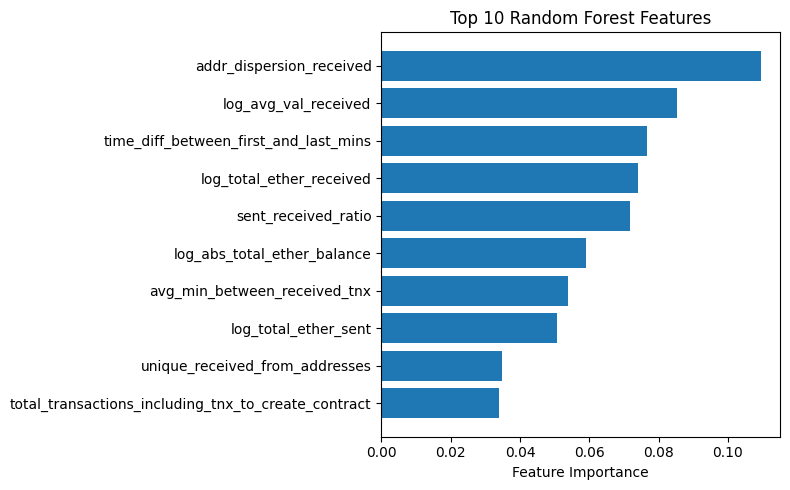

In [41]:
#feature importance: bar graph
plt.figure(figsize=(8, 5))

plt.barh(
    rf_top_features["feature"],
    rf_top_features["importance_rf"]
)

plt.xlabel("Feature Importance")
plt.title("Top 10 Random Forest Features")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

### Conclusion: 

Feature importance analysis was conducted using the Random Forest model, with validation against Gradient Boosting to assess consistency across models.

The results show strong agreement between the two ensemble models, with several key features consistently ranked as highly influential. These include:

Address dispersion (received) — indicating interaction with multiple counterparties, potentially reflecting fund distribution or layering behaviour.
Transaction timing features (e.g., average time between transactions, total activity window) — capturing rapid or compressed transaction patterns commonly associated with fraudulent activity.
Transaction value and balance features (e.g., total received, account balance) — highlighting abnormal transaction volumes and fund accumulation.
Sent-to-received ratio — reflecting imbalances in fund flow, which may indicate account draining or extraction patterns.

Notably, log_abs_total_ether_balance emerged as the most influential feature in Gradient Boosting, reinforcing the importance of balance-related behaviour in distinguishing fraudulent accounts.

While some features were model-specific, the overall consistency across Random Forest and Gradient Boosting suggests that the identified variables represent robust and reliable indicators of fraud rather than model-specific artefacts.

Overall, the models rely primarily on behavioural, transactional, and network-based signals, aligning with known characteristics of fraudulent financial activity and supporting their use in a risk scoring framework.

## Part 4: Risk Scoring

In [34]:
# generate fraud risk scores (probability of class = 1) based on random forest
risk_scores = best_rf.predict_proba(X)[:, 1]

In [35]:
#creating final risk scored dataset
risk_scored_wallets = X.copy()

risk_scored_wallets["address"] = addresses.values
risk_scored_wallets["actual_label"] = y.values
risk_scored_wallets["risk_score"] = risk_scores

In [36]:
#adding risk levels
def assign_risk(score):
    if score >= 0.7:
        return "High Risk"
    elif score >= 0.4:
        return "Medium Risk"
    else:
        return "Low Risk"

risk_scored_wallets["risk_level"] = risk_scored_wallets["risk_score"].apply(assign_risk)

In [37]:
#reordering columns for presentation
risk_scored_wallets = risk_scored_wallets[
    ["address",
     "actual_label",
     "risk_score",
     "risk_level"] +
    list(X.columns)
]

risk_scored_wallets.head()

,address,actual_label,risk_score,risk_level,avg_min_between_sent_tnx,avg_min_between_received_tnx,time_diff_between_first_and_last_mins,sent_tnx,received_tnx,number_of_created_contracts,...,received_range_ratio,addr_dispersion_sent,addr_dispersion_received,erc20_tx_ratio,erc20_sent_flag,log_erc20_uniq_sent_addr,log_erc20_uniq_rec_addr,erc20_addr_balance_ratio,log_erc20_unique_tokens_sent,log_erc20_unique_tokens_rec
0,0x00009277775ac7d0d59eaad8fee3d10ac6c805e8,0,0.021665,Low Risk,844.26,1093.71,704785.63,721,89,0,...,6.035537,0.163435,0.444444,0.326757,1,3.433987,4.007333,0.545455,3.688879,4.060443
1,0x0002b44ddb1476db43c868bd494422ee4c136fed,0,0.086787,Low Risk,12709.07,2958.44,1218216.73,94,8,0,...,1.885904,0.147368,0.555556,0.077670,1,0.693147,1.791759,0.166667,0.693147,2.079442
2,0x0002bda54cb772d040f779e88eb453cac0daa244,0,0.608182,Medium Risk,246194.54,2434.02,516729.30,2,10,0,...,0.857641,0.666667,0.909091,0.615385,0,0.000000,2.079442,0.000000,0.000000,2.197225
3,0x00038e6ba2fd5c09aedb96697c8d7b8fa6632e5e,0,0.004941,Low Risk,10219.60,15785.09,397555.90,25,9,0,...,4.975677,0.500000,0.700000,0.400000,1,1.098612,2.484907,0.166667,0.693147,2.484907
4,0x00062d1dd1afb6fb02540ddad9cdebfe568e0d89,0,0.058695,Low Risk,36.61,10707.77,382472.42,4598,20,1,...,3.487355,0.004131,0.333333,0.009091,1,1.609438,3.178054,0.166667,1.945910,3.332205


In [38]:
risk_scored_wallets["risk_level"].value_counts(normalize=True)

risk_level
Low Risk       0.756520
High Risk      0.196923
Medium Risk    0.046557
Name: proportion, dtype: float64

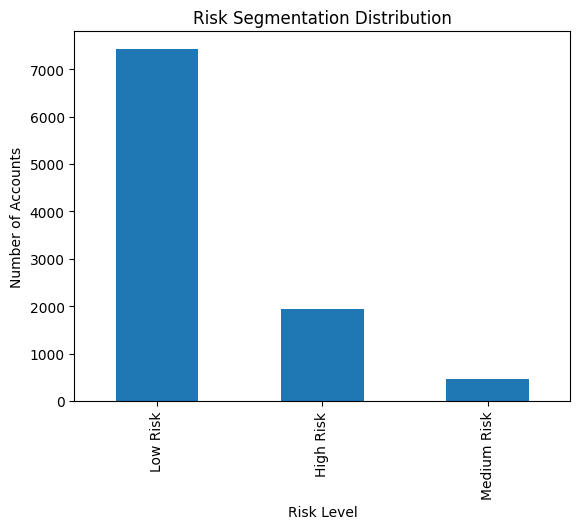

In [42]:
risk_scored_wallets["risk_level"].value_counts().plot(kind="bar")
plt.title("Risk Segmentation Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Accounts")
plt.show()

In [40]:
risk_scored_wallets.to_csv("risk_scored_wallets.csv", index=False)